<img src="../Pierian-Data-Logo.PNG">
<br>
<strong><center>Copyright 2019. Created by Jose Marcial Portilla.</center></strong>

In [1]:
!nvidia-smi

Thu May 28 00:05:29 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   51C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# MNIST Code Along with CNN
Now that we've seen the results of an artificial neural network model on the <a href='https://en.wikipedia.org/wiki/MNIST_database'>MNIST dataset</a>, let's work the same data with a <a href='https://en.wikipedia.org/wiki/Convolutional_neural_network'>Convolutional Neural Network</a> (CNN).
Make sure to watch the theory lectures! You'll want to be comfortable with:
* convolutional layers
* filters/kernels
* pooling
* depth, stride and zero-padding

Note that in this exercise there is no need to flatten the MNIST data, as a CNN expects 2-dimensional data.

## Perform standard imports

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [3]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

In [4]:
from sklearn.metrics import confusion_matrix

In [67]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'svg'

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


## Load the MNIST dataset
PyTorch makes the MNIST train and test datasets available through <a href='https://pytorch.org/docs/stable/torchvision/index.html'><tt><strong>torchvision</strong></tt></a>. The first time they're called, the datasets will be downloaded onto your computer to the path specified. From that point, torchvision will always look for a local copy before attempting another download.

Refer to the previous section for explanations of transformations, batch sizes and <a href='https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader'><tt><strong>DataLoader</strong></tt></a>.

In [7]:
transform = transforms.ToTensor()

train_data = datasets.MNIST(root='../Data', train=True, download=True, transform=transform)
test_data = datasets.MNIST(root='../Data', train=False, download=True, transform=transform)

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 481kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.48MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.46MB/s]


In [8]:
train_data

Dataset MNIST
    Number of datapoints: 60000
    Root location: ../Data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [9]:
test_data

Dataset MNIST
    Number of datapoints: 10000
    Root location: ../Data
    Split: Test
    StandardTransform
Transform: ToTensor()

### Create loaders
When working with images, we want relatively small batches; a batch size of 4 is not uncommon.

In [10]:
train_loader = DataLoader(dataset=train_data, batch_size=10, shuffle=True)
test_loader = DataLoader(dataset=test_data, batch_size=10, shuffle=False)

## Define a convolutional model
In the previous section we used only fully connected layers, with an input layer of 784 (our flattened 28x28 images), hidden layers of 120 and 84 neurons, and an output size representing 10 possible digits.

This time we'll employ two convolutional layers and two pooling layers before feeding data through fully connected hidden layers to our output. The model follows CONV/RELU/POOL/CONV/RELU/POOL/FC/RELU/FC.

<div class="alert alert-info"><strong>Let's walk through the steps we're about to take.</strong><br>

1. Extend the base Module class:
   
<tt><font color=black>class ConvolutionalNetwork(nn.Module):<br>
&nbsp;&nbsp;&nbsp;&nbsp;def \_\_init\_\_(self):<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;super().\_\_init\_\_()</font></tt><br>

2. Set up the convolutional layers with <a href='https://pytorch.org/docs/stable/nn.html#conv2d'><tt><strong>torch.nn.Conv2d()</strong></tt></a><br><br>The first layer has one input channel (the grayscale color channel). We'll assign 6 output channels for feature extraction. We'll set our kernel size to 3 to make a 3x3 filter, and set the step size to 1.<br>
<tt><font color=black>&nbsp;&nbsp;&nbsp;&nbsp;self.conv1 = nn.Conv2d(1, 6, 3, 1)</font></tt><br>
The second layer will take our 6 input channels and deliver 16 output channels.<br>
<tt><font color=black>&nbsp;&nbsp;&nbsp;&nbsp;self.conv2 = nn.Conv2d(6, 16, 3, 1)</font></tt><br><br>

3. Set up the fully connected layers with <a href='https://pytorch.org/docs/stable/nn.html#linear'><tt><strong>torch.nn.Linear()</strong></tt></a>.<br><br>The input size of (5x5x16) is determined by the effect of our kernels on the input image size. A 3x3 filter applied to a 28x28 image leaves a 1-pixel edge on all four sides. In one layer the size changes from 28x28 to 26x26. We could address this with zero-padding, but since an MNIST image is mostly black at the edges, we should be safe ignoring these pixels. We'll apply the kernel twice, and apply pooling layers twice, so our resulting output will be 
$\;(((28-2)/2)-2)/2 = 5.5\;$ which rounds down to 5 pixels per side.<br>
<tt><font color=black>&nbsp;&nbsp;&nbsp;&nbsp;self.fc1 = nn.Linear(5\*5\*16, 120)</font></tt><br>
<tt><font color=black>&nbsp;&nbsp;&nbsp;&nbsp;self.fc2 = nn.Linear(120, 84)</font></tt><br>
<tt><font color=black>&nbsp;&nbsp;&nbsp;&nbsp;self.fc3 = nn.Linear(84, 10)</font></tt><br>
See below for a more detailed look at this step.<br><br>

4. Define the forward method.<br><br>Activations can be applied to the convolutions in one line using <a href='https://pytorch.org/docs/stable/nn.html#id27'><tt><strong>F.relu()</strong></tt></a> and pooling is done using <a href='https://pytorch.org/docs/stable/nn.html#maxpool2d'><tt><strong>F.max_pool2d()</strong></tt></a><br>
<tt><font color=black>def forward(self, X):<br>
&nbsp;&nbsp;&nbsp;&nbsp;X = F.relu(self.conv1(X))<br>
&nbsp;&nbsp;&nbsp;&nbsp;X = F.max_pool2d(X, 2, 2)<br>
&nbsp;&nbsp;&nbsp;&nbsp;X = F.relu(self.conv2(X))<br>
&nbsp;&nbsp;&nbsp;&nbsp;X = F.max_pool2d(X, 2, 2)<br>
</font></tt>Flatten the data for the fully connected layers:<br><tt><font color=black>
&nbsp;&nbsp;&nbsp;&nbsp;X = X.view(-1, 5\*5\*16)<br>
&nbsp;&nbsp;&nbsp;&nbsp;X = F.relu(self.fc1(X))<br>
&nbsp;&nbsp;&nbsp;&nbsp;X = self.fc2(X)<br>
&nbsp;&nbsp;&nbsp;&nbsp;return F.log_softmax(X, dim=1)</font></tt>
</div>

<div class="alert alert-danger"><strong>Breaking down the convolutional layers</strong> (this code is for illustration purposes only.)</div>

In [11]:
# Define layers
conv1 = nn.Conv2d(in_channels = 1 , # because MNIST is black and white.
                  out_channels = 6, # number of filters
                  kernel_size = 3, # size of the filter, so the filter is 3x3 (3 rows and 3 columns).
                  stride = 1 # step size
                  )

conv2 = nn.Conv2d(in_channels = 6, # number of output channels from the previous layer.
                  out_channels = 16, # number of filters
                  kernel_size = 3, # size of the filter: so the filter is 3x3 (3 rows and 3 columns).
                  stride = 1 # step size
                  )

In [12]:
# Grab the first MNIST record
for batch_index , (X_train, y_train) in enumerate(train_data):
    break

In [13]:
X_train.shape # 1 x 28 x 28 (1: channel, 28: rows, 28: columns)

torch.Size([1, 28, 28])

Now we can apply the first convolutional layer to the data. The output will be a 4D tensor with dimensions (number of samples, number of output channels, height, width). The number of output channels is determined by the second argument in the `Conv2d` layer, which we set to 6. The height and width are determined by the kernel size and stride. With a kernel size of 3 and a stride of 1, the height and width will be reduced by 2 pixels on each side, resulting in a new size of 26x26.<br>


In [14]:
conv1(X_train).shape

torch.Size([6, 26, 26])

In [15]:
len(conv1(X_train))

6

In [16]:
conv1(X_train)[0].shape , conv1(X_train)[0].size()

(torch.Size([26, 26]), torch.Size([26, 26]))

So we can sum up the effect of the convolutional and pooling layers as follows:<br>
| Layer | Output Shape | Explanation |
| --- | --- | --- |
| Input | (number of samples, 1, 28, 28) | Original MNIST data reshaped for convolutional layers |
| Conv1 | (number of samples, 6, 26, 26) | 6 output channels, height and width reduced by 2 due to 3x3 kernel |


In [ ]:
X_train = F.relu(conv1(X_train))
X_train.shape , len(X_train)

In [18]:
X_train.shape , len(X_train)

(torch.Size([6, 26, 26]), 6)

So, applying the activation function does not imapact on the size of the tensor. <br>
<br>

Now we apply the pooling layer:<br>
| Layer | Output Shape | Explanation |
| --- | --- | --- |
| Pool1 | (number of samples, 6, 13, 13) | Max pooling with kernel size 2 and stride 2 reduces height (26) and width (26) by half (26/2) = 13|


In [19]:
# Run the first pooling layer
X_train = F.max_pool2d(input = X_train , kernel_size = 2, stride = 2)
# the shape of  is now 1 , 6, 13, 13. why? because the kernel is 2x2 and the stride is 2. So the output is 13x13.
print(X_train.shape)

torch.Size([6, 13, 13])


Now pass the data through the second convolutional layer:<br>
| Layer | Output Shape | Explanation |
| --- | --- | --- |
| Conv2 | (number of samples, 16, 11, 11) | 16 output channels, previous height (13) and width (13) reduced by 2 due to 3x3 kernel |


In [20]:
# Now, we can pass x into the second convolutional layer: conv2(x), then apply a ReLU activation
X_train = F.relu(conv2(X_train))
print(X_train.shape)

torch.Size([16, 11, 11])


Now we apply the second max pooling layer:<br>
| Layer | Output Shape | Explanation |
| --- | --- | --- |
| Pool2 | (number of samples, 16, 5, 5) | Max pooling with kernel size 2 and stride 2 reduces height(11) and width (11) by half (11/2) |

In [21]:
X_train = F.max_pool2d(input = X_train , kernel_size = 2, stride = 2)
print(X_train.shape)

torch.Size([16, 5, 5])


Now, we would flatten the data for the fully connected layers, which would give us a shape of (number of samples, $16\times 5\times 5$) or (number of samples, 400). This is the input size for our first fully connected layer. That's the main reason why we will define the first fully connected layer with an input size of $16\times 5\times 5$:
```python
self.fc1 = nn.Linear(in_features = 5*5*16 , out_features = 120)
```

In [22]:
X_train = X_train.view(-1 , 16*5*5)
print(X_train.shape)

torch.Size([1, 400])


<div class="alert alert-danger"><strong>This is how the convolution output is passed into the fully connected layers.</strong></div>

Now let's run the code.

In [23]:
class ConvolutionNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels = 1 , out_channels = 6 , kernel_size = 3 , stride = 1)
        self.conv2 = nn.Conv2d(in_channels = 6 , out_channels = 16 , kernel_size = 3, stride = 1)

        self.fc1 = nn.Linear(in_features = 16*5*5 , out_features = 120)
        self.fc2 = nn.Linear(in_features = 120 , out_features = 84)
        self.fc3 = nn.Linear(in_features = 84, out_features = 10) # 10: number of classes


    def forward(self , X): # X.shape = (batch_size, 1, 28, 28)
        X = F.relu(self.conv1(X)) 
        # X.shape = (batch_size, out_channels, rows, columns) = (batch_size, 6, 26, 26) ; 26 = 28 - kernel_size + stride
        X = F.max_pool2d(input = X , kernel_size = 2 , stride = 2) 
        # X.shape = (batch_size,6 = out_channels, 13, 13) ; 13 = 26//2 = 26//(kernel_size-stride) (floor division)
        X = F.relu(input = self.conv2(X)) 
        # X.shape = (batch_size, out_channels, rows, columns) = (batch_size, 16, 11, 11); 11 = 13 - kernel_size + stride
        X = F.max_pool2d(input = X , kernel_size = 2 , stride = 2) 
        # X.shape = (batch_size, 16, 5, 5) because 11//2=5 (floor division), we apply the flatten layer:
        X = X.view(-1 , 5*5*16)
        X = F.relu(self.fc1(X))
        X = F.relu(self.fc2(X))
        X = self.fc3(X)
        return F.log_softmax(input = X , dim = 1)


In [24]:
torch.manual_seed(seed = 42)
model = ConvolutionNetwork()

In [25]:
model.parameters

<bound method Module.parameters of ConvolutionNetwork(
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)>

Including the bias terms for each layer, the total number of parameters being trained is:<br>

\begin{split}
& (1\times6\times3\times3) + 6 \\
& + (6\times16\times3\times3) + 16 \\
& + (400\times120) + 120 \\
& + (120\times84) + 84 \\
& +(84\times10)+10 \\
&= 54 + 6 + 864 + 16 + 48000 + 120 + 10080 + 84 + 840 + 10 \\
&= 60,074
\end{split}


In [30]:
def count_parameters(model):
    params = [p.numel() for p in model.parameters() if p.requires_grad]
    for item in params:
        print(f'{item:>6,}')
    print(f'______\n{sum(params):>6,}')

In [31]:
count_parameters(model)

    54
     6
   864
    16
48,000
   120
10,080
    84
   840
    10
______
60,074


## Define loss function & optimizer

In [32]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

## Train the model
This time we'll feed the data directly into the model without flattening it first.

In [ ]:
import time
start_time = time.time()

epochs = 30

train_losses = []
train_correct = []

test_losses = []
test_correct = []

for epoch in range(epochs):
    trn_corr = 0
    tst_corr = 0
    
    # Run the training batches
    for batch_index_train , (X_train, y_train) in enumerate(train_loader):
        batch_index_train += 1
        
        # Apply the model
        y_pred = model(X_train) # we don't flatten X-train here
        loss_train = criterion(y_pred , y_train)
 
        # Tally the number of correct predictions
        train_predicted = torch.max(y_pred.data, 1)[1]
        train_batch_corr = (train_predicted == y_train).sum()
        trn_corr += train_batch_corr
        
        # Update parameters
        optimizer.zero_grad()
        loss_train.backward()
        optimizer.step()
        
        # Print interim results
        if batch_index_train%200 == 0:
            print(f'epoch: {epoch:2} --- batch: {batch_index_train:4} --- [{10*batch_index_train:6}/60000] ---  loss: {loss_train.item():10.8f}  \
train accuracy: {trn_corr.item()*100/(10*batch_index_train):7.3f}%')
    
    # Update train loss & accuracy for the epoch:   
    train_losses.append(loss_train)
    train_correct.append(trn_corr)
        
    # Run the testing batches
    with torch.no_grad():
        for batch_index_test, (X_test, y_test) in enumerate(test_loader):

            # Apply the model
            y_val = model(X_test)
            loss_test = criterion(y_val, y_test)

            # Tally the number of correct predictions
            test_predicted = torch.max(y_val.data, 1)[1] 
            tst_corr += (test_predicted == y_test).sum()
            

        test_losses.append(loss_test)
        test_correct.append(tst_corr)

end_time = time.time()        
print(f'\nDuration: {(end_time - start_time)/60:.0f} minutes & {end_time - start_time:.0f} seconds') # print the time elapsed            

epoch:  0 --- batch:  200 --- [  2000/60000] ---  loss: 0.00000024  train accuracy:  99.900%
epoch:  0 --- batch:  400 --- [  4000/60000] ---  loss: 0.00000049  train accuracy:  99.875%
epoch:  0 --- batch:  600 --- [  6000/60000] ---  loss: 0.00000000  train accuracy:  99.867%
epoch:  0 --- batch:  800 --- [  8000/60000] ---  loss: 0.00231996  train accuracy:  99.875%
epoch:  0 --- batch: 1000 --- [ 10000/60000] ---  loss: 0.00000005  train accuracy:  99.880%
epoch:  0 --- batch: 1200 --- [ 12000/60000] ---  loss: 0.00000000  train accuracy:  99.900%
epoch:  0 --- batch: 1400 --- [ 14000/60000] ---  loss: 0.01603828  train accuracy:  99.893%
epoch:  0 --- batch: 1600 --- [ 16000/60000] ---  loss: 0.00000154  train accuracy:  99.881%
epoch:  0 --- batch: 1800 --- [ 18000/60000] ---  loss: 0.00000000  train accuracy:  99.839%
epoch:  0 --- batch: 2000 --- [ 20000/60000] ---  loss: 0.00000000  train accuracy:  99.845%
epoch:  0 --- batch: 2200 --- [ 22000/60000] ---  loss: 0.00000000  tr

In [ ]:
# train_losses = torch.stack(train_losses)
# test_losses = torch.stack(test_losses)

In [50]:
train_losses

[tensor(0.0304, grad_fn=<NllLossBackward0>),
 tensor(0., grad_fn=<NllLossBackward0>),
 tensor(1.5497e-07, grad_fn=<NllLossBackward0>),
 tensor(2.3842e-08, grad_fn=<NllLossBackward0>),
 tensor(3.9236e-05, grad_fn=<NllLossBackward0>),
 tensor(0.0002, grad_fn=<NllLossBackward0>),
 tensor(0., grad_fn=<NllLossBackward0>),
 tensor(8.4698e-05, grad_fn=<NllLossBackward0>),
 tensor(0., grad_fn=<NllLossBackward0>),
 tensor(0., grad_fn=<NllLossBackward0>),
 tensor(4.1007e-06, grad_fn=<NllLossBackward0>),
 tensor(7.1525e-07, grad_fn=<NllLossBackward0>),
 tensor(0., grad_fn=<NllLossBackward0>),
 tensor(4.6252e-06, grad_fn=<NllLossBackward0>),
 tensor(0., grad_fn=<NllLossBackward0>),
 tensor(0., grad_fn=<NllLossBackward0>),
 tensor(1.3113e-06, grad_fn=<NllLossBackward0>),
 tensor(0., grad_fn=<NllLossBackward0>),
 tensor(0., grad_fn=<NllLossBackward0>),
 tensor(0., grad_fn=<NllLossBackward0>),
 tensor(0., grad_fn=<NllLossBackward0>),
 tensor(0., grad_fn=<NllLossBackward0>),
 tensor(0., grad_fn=<NllLo

In [57]:
torch.stack(train_losses)

tensor([3.0375e-02, 0.0000e+00, 1.5497e-07, 2.3842e-08, 3.9236e-05, 2.1304e-04,
        0.0000e+00, 8.4698e-05, 0.0000e+00, 0.0000e+00, 4.1007e-06, 7.1525e-07,
        0.0000e+00, 4.6252e-06, 0.0000e+00, 0.0000e+00, 1.3113e-06, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        1.0729e-07, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
       grad_fn=<StackBackward0>)

In [58]:
torch.stack(train_losses).detach().numpy().size

30

In [59]:
torch.stack(test_losses).detach().numpy().size

30

## Plot the loss and accuracy comparisons

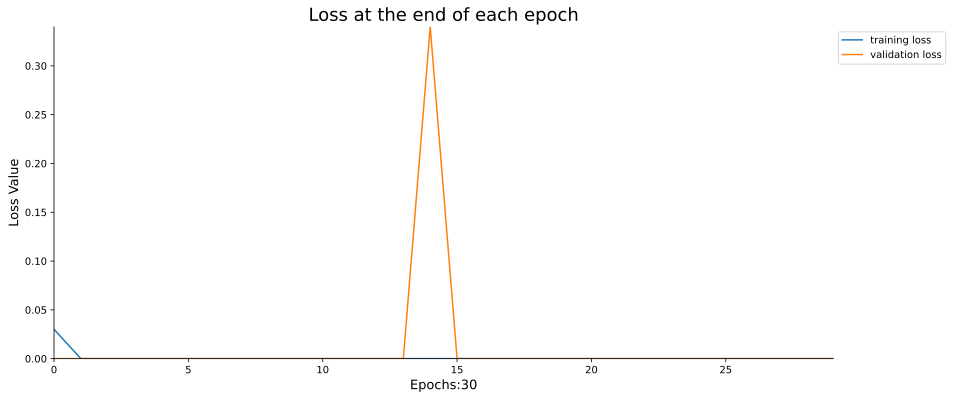

In [80]:
plt.figure(figsize=(14,6))

plt.plot(np.arange(epochs),torch.stack(train_losses).detach().numpy().round(2),label='training loss')
# plt.plot([loss.item() for loss in train_losses],
#          label='training loss')

plt.plot(np.arange(epochs),torch.stack(test_losses).detach().numpy().round(2), label='validation loss')
# plt.plot([loss.item() for loss in test_losses],
#          label='validation loss')
plt.title('Loss at the end of each epoch' , fontsize = 18)
plt.ylabel("Loss Value", fontsize = 13)
plt.xlabel("Epochs:30" , fontsize = 13)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.autoscale(enable=True , axis='both', tight=True)

plt.legend(bbox_to_anchor = (1,1), loc = 'upper left')
plt.show()

While there may be some overfitting of the training data, there is far less than we saw with the ANN model.

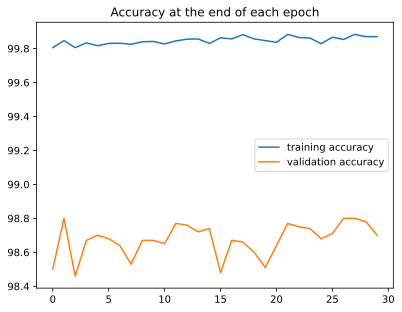

In [61]:
plt.plot([t/600 for t in train_correct], label='training accuracy')
plt.plot([t/100 for t in test_correct], label='validation accuracy')
plt.title('Accuracy at the end of each epoch')
plt.legend();

## Evaluate Test Data

In [62]:
# Extract the data all at once, not in batches
test_load_all = DataLoader(test_data, batch_size=10000, shuffle=False)

In [63]:
with torch.no_grad():
    correct = 0
    for X_test, y_test in test_load_all:
        y_val = model(X_test)  # we don't flatten the data this time
        predicted = torch.max(y_val,1)[1]
        correct += (predicted == y_test).sum()
print(f'Test accuracy: {correct.item()}/{len(test_data)} = {correct.item()*100/(len(test_data)):7.3f}%')

Test accuracy: 9870/10000 =  98.700%


Recall that our [784,120,84,10] ANN returned an accuracy of 97.25% after 10 epochs. And it used 105,214 parameters to our current 60,074.

## Display the confusion matrix

In [64]:
# print a row of values for reference
np.set_printoptions(formatter=dict(int=lambda x: f'{x:4}'))
print(np.arange(10).reshape(1,10))
print()

# print the confusion matrix
print(confusion_matrix(predicted.view(-1), y_test.view(-1)))

[[   0    1    2    3    4    5    6    7    8    9]]

[[ 971    0    1    0    1    0    3    0    2    0]
 [   1 1125    2    0    0    0    1    3    1    0]
 [   1    1 1010    1    0    0    0    8    1    0]
 [   0    0    4  998    0    7    0    0    2    0]
 [   0    0    2    0  977    0    3    2    0    7]
 [   0    3    0    4    0  882    3    1    1    4]
 [   4    3    1    0    2    1  948    0    1    0]
 [   1    1    4    3    0    1    0 1010    2    3]
 [   2    1    7    3    0    0    0    0  961    7]
 [   0    1    1    1    2    1    0    4    3  988]]


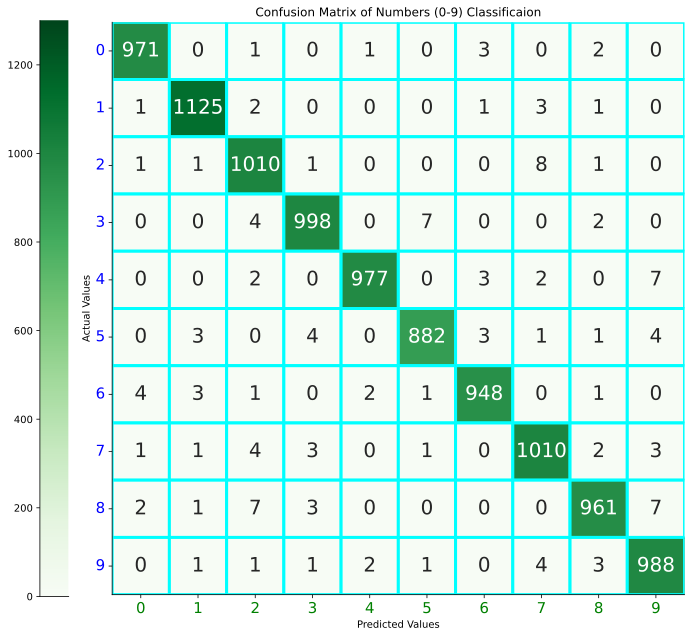

In [68]:
plt.figure(figsize=(13,13))
sns.heatmap(data = confusion_matrix(predicted.view(-1) , y_test.view(-1)),
            cmap ="Greens",
            vmin = 0,
            vmax = 1300,
            annot = True,
            annot_kws = {"size":20},
            linewidths = 3,
            linecolor = "cyan",
            xticklabels=list(range(10)),
            yticklabels=list(range(10)),
            square = True,
            fmt ="g",
            cbar_kws = {"shrink" : 0.8 ,
                        "pad" : 0.06  ,
                        "location" : "left" ,
                        "orientation" : "vertical"}
            ).set(
                xlabel = "Predicted Values",
                ylabel = "Actual Values",
                title = "Confusion Matrix of Numbers (0-9) Classificaion",
            )
plt.yticks(rotation=0 , fontsize = 15, color ="blue")
plt.xticks(fontsize = 15, color ="green")
sns.despine()

## Examine the misses
We can track the index positions of "missed" predictions, and extract the corresponding image and label. We'll do this in batches to save screen space.

In [69]:
misses = np.array([])
for i in range(len(predicted.view(-1))):
    if predicted[i] != y_test[i]:
        misses = np.append(misses,i).astype('int64')
        
# Display the number of misses
len(misses)

130

In [91]:
misses

array([  18,  115,  320,  326,  340,  445,  448,  449,  460,  495,  619,
        646,  726,  882,  924,  926,  947, 1014, 1021, 1112, 1128, 1178,
       1182, 1226, 1242, 1247, 1260, 1290, 1299, 1312, 1393, 1414, 1459,
       1520, 1522, 1527, 1530, 1569, 1621, 1681, 1709, 1721, 1878, 1901,
       1903, 2035, 2070, 2098, 2118, 2129, 2185, 2195, 2280, 2314, 2437,
       2462, 2488, 2597, 2607, 2648, 2654, 2770, 2854, 2863, 2896, 2921,
       2927, 2939, 2953, 3023, 3073, 3100, 3225, 3316, 3330, 3422, 3520,
       3601, 3662, 3681, 3727, 3742, 3767, 3871, 3941, 3985, 4007, 4078,
       4176, 4199, 4201, 4248, 4284, 4350, 4497, 4507, 4740, 4761, 4814,
       4823, 4838, 4880, 5127, 5331, 5449, 5634, 5642, 5997, 6166, 6555,
       6560, 6572, 6574, 6597, 6625, 6651, 6783, 7216, 8102, 8160, 8325,
       8382, 9009, 9613, 9634, 9642, 9664, 9692, 9729, 9839])

In [70]:
# Display the first 10 index positions
misses[:10]

array([  18,  115,  320,  326,  340,  445,  448,  449,  460,  495])

Now let's split the misses inot batches of 12.

In [103]:
(len(misses)//r) + 1

11

In [92]:
np.array_split(misses, (len(misses)//r) + 1)

[array([  18,  115,  320,  326,  340,  445,  448,  449,  460,  495,  619,
         646]),
 array([ 726,  882,  924,  926,  947, 1014, 1021, 1112, 1128, 1178, 1182,
        1226]),
 array([1242, 1247, 1260, 1290, 1299, 1312, 1393, 1414, 1459, 1520, 1522,
        1527]),
 array([1530, 1569, 1621, 1681, 1709, 1721, 1878, 1901, 1903, 2035, 2070,
        2098]),
 array([2118, 2129, 2185, 2195, 2280, 2314, 2437, 2462, 2488, 2597, 2607,
        2648]),
 array([2654, 2770, 2854, 2863, 2896, 2921, 2927, 2939, 2953, 3023, 3073,
        3100]),
 array([3225, 3316, 3330, 3422, 3520, 3601, 3662, 3681, 3727, 3742, 3767,
        3871]),
 array([3941, 3985, 4007, 4078, 4176, 4199, 4201, 4248, 4284, 4350, 4497,
        4507]),
 array([4740, 4761, 4814, 4823, 4838, 4880, 5127, 5331, 5449, 5634, 5642,
        5997]),
 array([6166, 6555, 6560, 6572, 6574, 6597, 6625, 6651, 6783, 7216, 8102]),
 array([8160, 8325, 8382, 9009, 9613, 9634, 9642, 9664, 9692, 9729, 9839])]

In [90]:
iter(np.array_split(misses, (len(misses)//r) + 1))

In [105]:
for i in iter(np.array_split(misses, (len(misses)//r) + 1)):
    print(i, ": with the length of" , len(i) , end ="\n")

[  18  115  320  326  340  445  448  449  460  495  619  646] : with the length of 12
[ 726  882  924  926  947 1014 1021 1112 1128 1178 1182 1226] : with the length of 12
[1242 1247 1260 1290 1299 1312 1393 1414 1459 1520 1522 1527] : with the length of 12
[1530 1569 1621 1681 1709 1721 1878 1901 1903 2035 2070 2098] : with the length of 12
[2118 2129 2185 2195 2280 2314 2437 2462 2488 2597 2607 2648] : with the length of 12
[2654 2770 2854 2863 2896 2921 2927 2939 2953 3023 3073 3100] : with the length of 12
[3225 3316 3330 3422 3520 3601 3662 3681 3727 3742 3767 3871] : with the length of 12
[3941 3985 4007 4078 4176 4199 4201 4248 4284 4350 4497 4507] : with the length of 12
[4740 4761 4814 4823 4838 4880 5127 5331 5449 5634 5642 5997] : with the length of 12
[6166 6555 6560 6572 6574 6597 6625 6651 6783 7216 8102] : with the length of 11
[8160 8325 8382 9009 9613 9634 9642 9664 9692 9729 9839] : with the length of 11


In [101]:
# Set up an iterator to feed batched rows
r = 12   # row size
row = iter(np.array_split(misses,len(misses)//r+1))

In [102]:
print(next(row))
print(next(row))
print(next(row))
print(next(row))
print(next(row))
print(next(row))

[  18  115  320  326  340  445  448  449  460  495  619  646]
[ 726  882  924  926  947 1014 1021 1112 1128 1178 1182 1226]
[1242 1247 1260 1290 1299 1312 1393 1414 1459 1520 1522 1527]
[1530 1569 1621 1681 1709 1721 1878 1901 1903 2035 2070 2098]
[2118 2129 2185 2195 2280 2314 2437 2462 2488 2597 2607 2648]
[2654 2770 2854 2863 2896 2921 2927 2939 2953 3023 3073 3100]


Now that everything is set up, run and re-run the cell below to view all of the missed predictions.<br>
Use <kbd>Ctrl+Enter</kbd> to remain on the cell between runs. You'll see a <tt>StopIteration</tt> once all the misses have been seen.

Index: [3941 3985 4007 4078 4176 4199 4201 4248 4284 4350 4497 4507]
Label: [   4    9    7    9    2    7    1    2    9    2    8    1]
Guess: [   6    4    9    8    7    9    7    9    5    8    7    9]


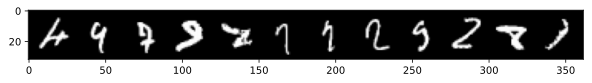

In [109]:
nextrow = next(row)
print("Index:", nextrow)
print("Label:", y_test.index_select(0,torch.tensor(nextrow)).numpy())
print("Guess:", predicted.index_select(0,torch.tensor(nextrow)).numpy())

images = X_test.index_select(0,torch.tensor(nextrow))
im = make_grid(images, nrow=r)
plt.figure(figsize=(10,4))
plt.imshow(np.transpose(im.numpy(), (1, 2, 0)))
plt.show()

## Run a new image through the model
We can also pass a single image through the model to obtain a prediction.
Pick a number from 0 to 9999, assign it to "x", and we'll use that value to select a number from the MNIST test set.

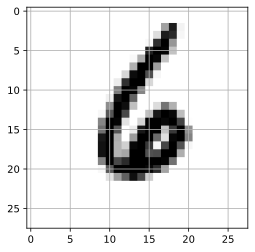

In [107]:
x = 2026
plt.figure(figsize=(4,4))
plt.imshow(test_data[x][0].reshape((28,28)), cmap="gist_yarg")
plt.grid()
plt.show()

In [113]:
model.eval()
with torch.no_grad():
    new_pred = model(test_data[x][0].view(1,1,28,28))

new_pred

tensor([[ -71.3841,  -89.8942,  -78.8768, -140.1354,  -88.3984,  -67.6941,
            0.0000, -191.1581, -100.9065, -137.6178]])

In [115]:
new_pred.argmax()

tensor(6)

In [116]:
new_pred.argmax().item()

6

So we can wrap up the above lines of code into a one:

In [108]:
model.eval()
with torch.no_grad():
    new_pred = model(test_data[x][0].view(1,1,28,28)).argmax()
print("Predicted value:",new_pred.item())

Predicted value: 6


## Great job!